# Module 06: OpenCV for Computer Vision & Machine Learning
## Notebook 06: Practical Computer Vision & Machine Learning Integration

Computer vision achieves its highest impact when paired with modern Machine Learning. In this notebook, we bridge classical feature engineering, morphological segmentation, statistical image classification with Scikit-Learn, and Deep Learning inference with OpenCV's DNN module.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Implement **Multi-Scale Template Matching** over an image pyramid to locate objects with scale variation.
2. Segment touching and overlapping objects using the **Marker-Controlled Watershed Algorithm** with the Euclidean Distance Transform.
3. Compute **Histogram of Oriented Gradients (HOG)** descriptors for visual feature engineering.
4. Train and evaluate an end-to-end **Machine Learning Image Classifier** combining OpenCV HOG descriptors with a Scikit-Learn Support Vector Machine (`SVC`).
5. **Advanced:** Run Deep Learning inference using OpenCV's optimized **`cv2.dnn`** module and understand `cv2.dnn.blobFromImage()`.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

img_dir = "images" if os.path.exists("images") else "../images"
print(f"OpenCV Version: {cv2.__version__}")

OpenCV Version: 4.14.0


### 1. Multi-Scale Template Matching
Standard `cv2.matchTemplate()` slides a template across an image and computes normalized correlation coefficients (`cv2.TM_CCOEFF_NORMED`). However, standard template matching fails if the target in the scene differs in scale.
**Multi-Scale Template Matching** solves this by constructing an image scale pyramid:
1. Resize the target scene across a range of scale factors (e.g. from $0.5\times$ to $1.5\times$).
2. Run `cv2.matchTemplate()` at each scale and find the global maximum response with `cv2.minMaxLoc()`.
3. Track the best scale and project the bounding box back to original coordinates.

Optimal Pyramid Scale: 1.20x, Correlation Score: 0.626


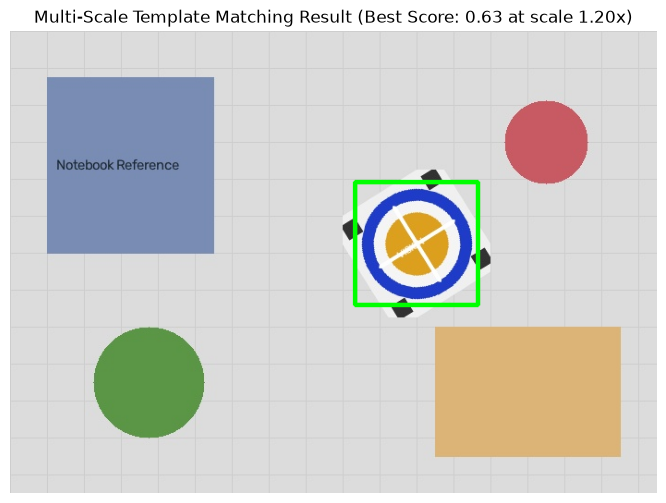

In [2]:
query_img = cv2.imread(os.path.join(img_dir, "query_object.png"))
scene_img = cv2.imread(os.path.join(img_dir, "scene_search.jpg"))

query_gray = cv2.cvtColor(query_img, cv2.COLOR_BGR2GRAY)
scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)
t_h, t_w = query_gray.shape[:2]

best_max_val = -1
best_match = None
best_scale = 1.0

# Search across scales from 0.5x to 1.3x in steps
for scale in np.linspace(0.5, 1.3, 17):
    # Resize scene according to scale
    resized_w = int(scene_gray.shape[1] * scale)
    resized_h = int(scene_gray.shape[0] * scale)
    if resized_w < t_w or resized_h < t_h:
        continue

    resized_scene = cv2.resize(scene_gray, (resized_w, resized_h), interpolation=cv2.INTER_AREA)
    r_factor = scene_gray.shape[1] / float(resized_w)

    # Compute normalized cross-correlation
    res = cv2.matchTemplate(resized_scene, query_gray, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    if max_val > best_max_val:
        best_max_val = max_val
        best_match = (int(max_loc[0] * r_factor), int(max_loc[1] * r_factor))
        best_scale = scale

print(f"Optimal Pyramid Scale: {best_scale:.2f}x, Correlation Score: {best_max_val:.3f}")

# Draw detected bounding box at original scale
matched_vis = scene_img.copy()
box_w = int(t_w * (1.0 / best_scale))
box_h = int(t_h * (1.0 / best_scale))
cv2.rectangle(matched_vis, best_match, (best_match[0] + box_w, best_match[1] + box_h), (0, 255, 0), 3)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(matched_vis, cv2.COLOR_BGR2RGB))
plt.title(f"Multi-Scale Template Matching Result (Best Score: {best_max_val:.2f} at scale {best_scale:.2f}x)")
plt.axis("off")
plt.show()

### 2. Marker-Controlled Watershed Segmentation
When biological cells, coins, or industrial parts touch or overlap, simple binary thresholding merges them into a single blob.
The **Watershed Algorithm** treats pixel intensities as topographic elevation surfaces (light pixels = peaks, dark pixels = valleys):
1. **Denoising & Binarization:** Clean input using Otsu thresholding and morphological opening.
2. **Sure Background:** Morphologically dilate foreground to establish regions guaranteed to be background.
3. **Sure Foreground Seeds (Distance Transform):** Compute Euclidean distance to nearest zero-pixel using `cv2.distanceTransform(..., cv2.DIST_L2, 5)`. Threshold peaks to isolate guaranteed object centers.
4. **Unknown Region:** Boundary zones $\text{Unknown} = \text{Sure Background} - \text{Sure Foreground}$.
5. **Marker Seeds:** Assign unique integer labels to each seed using `cv2.connectedComponents()`. Set unknown zone to 0.
6. **Watershed (`cv2.watershed`):** Flood topographic basins; boundaries where water sources meet are marked with label $-1$.

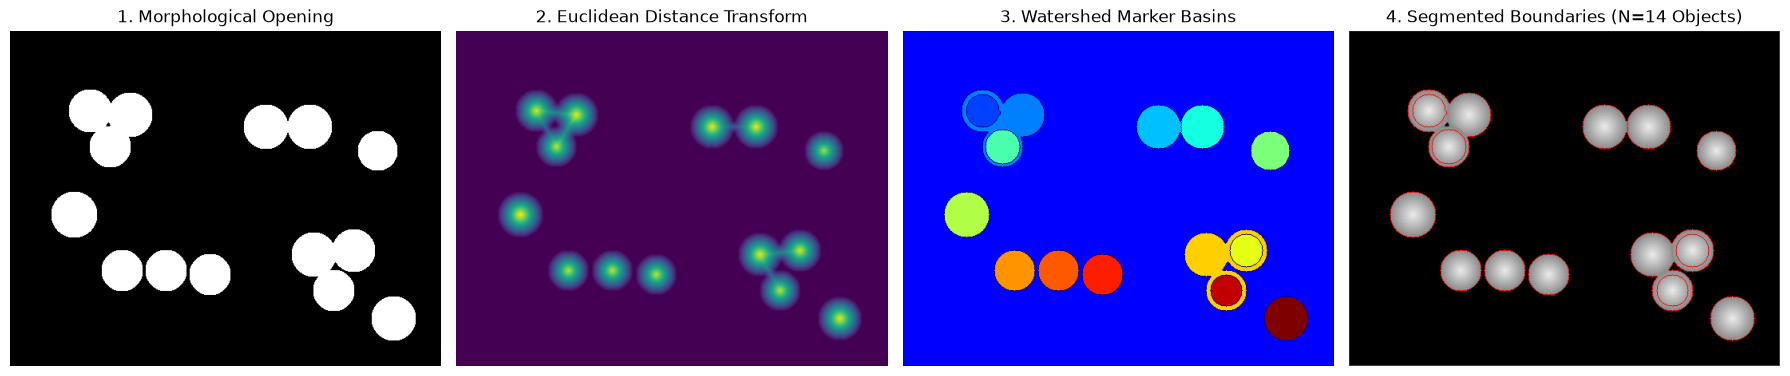

In [3]:
coins_bgr = cv2.imread(os.path.join(img_dir, "coins_cells.png"))
coins_gray = cv2.cvtColor(coins_bgr, cv2.COLOR_BGR2GRAY)

# 1. Binarization via Otsu's thresholding
_, thresh = cv2.threshold(coins_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Noise removal via morphological opening
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 3. Sure background via dilation
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 4. Sure foreground via Euclidean Distance Transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# 5. Unknown boundary region
unknown = cv2.subtract(sure_bg, sure_fg)

# 6. Marker labeling
ret, markers = cv2.connectedComponents(sure_fg)
# Add 1 to all labels so sure background is 1 instead of 0
markers = markers + 1
# Mark unknown region with 0
markers[unknown == 255] = 0

# 7. Apply Watershed
markers = cv2.watershed(coins_bgr.copy(), markers)

# Overlay segmented boundaries (where markers == -1) in bright red
watershed_vis = coins_bgr.copy()
watershed_vis[markers == -1] = [0, 0, 255]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(opening, cmap="gray")
axes[0].set_title("1. Morphological Opening")
axes[0].axis("off")

axes[1].imshow(dist_transform, cmap="viridis")
axes[1].set_title("2. Euclidean Distance Transform")
axes[1].axis("off")

axes[2].imshow(markers, cmap="jet")
axes[2].set_title("3. Watershed Marker Basins")
axes[2].axis("off")

axes[3].imshow(cv2.cvtColor(watershed_vis, cv2.COLOR_BGR2RGB))
axes[3].set_title(f"4. Segmented Boundaries (N={ret - 1} Objects)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### 3. Feature Engineering with HOG (Histogram of Oriented Gradients)
The **HOG descriptor** is one of the most successful classical feature representations in machine learning (popularized by Dalal and Triggs for human detection):
1. **Gradient Computation:** Computes $G_x$ and $G_y$.
2. **Spatial Cell Division:** Divides the image into small spatial cells (e.g. $8 \times 8$ pixels).
3. **Orientation Binning:** Bins gradient orientations into 9 angular bins ($0^\circ$ to $180^\circ$) weighted by gradient magnitude.
4. **Block Normalization:** Groups cells into overlapping blocks (e.g. $2 \times 2$ cells) and normalizes local contrast ($L_2$-norm) to achieve invariance to illumination and shadows.

In [4]:
# Configure HOGDescriptor
win_size = (64, 64)
block_size = (16, 16)
block_stride = (8, 8)
cell_size = (8, 8)
nbins = 9

hog = cv2.HOGDescriptor(
    win_size,
    block_size,
    block_stride,
    cell_size,
    nbins
)

# Extract HOG feature vector on a sample shape crop
sample_patch = cv2.resize(coins_gray[:120, :120], win_size)
hog_features = hog.compute(sample_patch)

print(f"HOG Descriptor feature dimension for 64x64 window: {hog_features.shape[0]} features")
print(f"HOG Vector summary: min={hog_features.min():.4f}, mean={hog_features.mean():.4f}, max={hog_features.max():.4f}")

HOG Descriptor feature dimension for 64x64 window: 1764 features
HOG Vector summary: min=0.0000, mean=0.0278, max=0.9950


### 4. End-to-End Vision + ML Classification Pipeline with Scikit-Learn
We now construct a full image classification pipeline:
1. **Dataset Synthesis:** Generate a synthetic dataset of 3 visual classes: **Circles (0)**, **Squares (1)**, and **Triangles (2)** with random positions, scales, line thicknesses, and Gaussian background noise ($N=600$ images).
2. **Feature Extraction:** Extract HOG feature vectors for all samples.
3. **Model Training:** Partition into 80/20 train/test split and train a Support Vector Classifier (`SVC` with RBF kernel).
4. **Evaluation:** Compute accuracy, precision, recall, and display the confusion matrix.

Extracting HOG features across dataset...
Dataset shape: (600, 1764), Labels shape: (600,)

              precision    recall  f1-score   support

      Circle       1.00      1.00      1.00        50
      Square       1.00      1.00      1.00        50
    Triangle       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



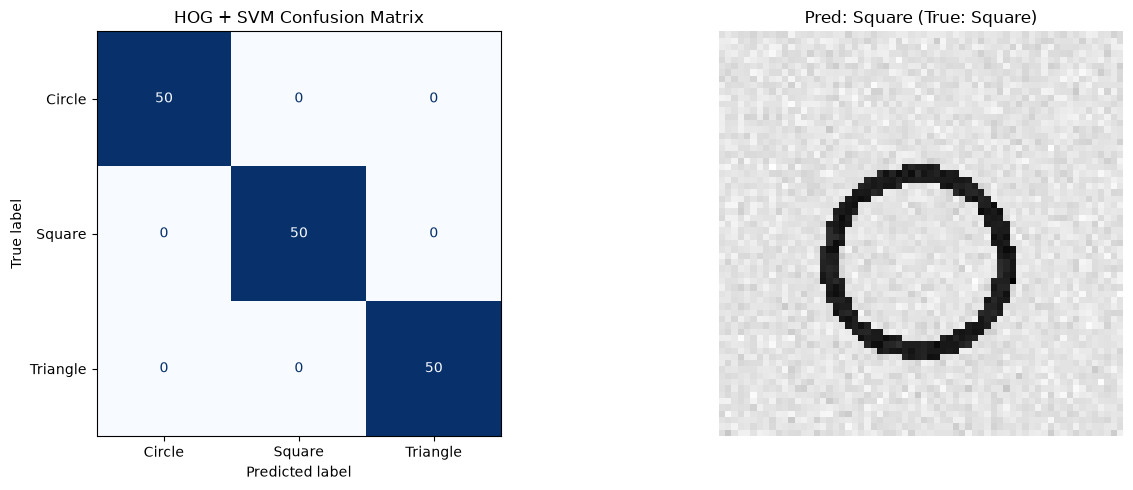

In [5]:
# 1. Synthesize multi-class image dataset
np.random.seed(42)
num_samples_per_class = 200
X_images = []
y_labels = []

for label in range(3):
    for _ in range(num_samples_per_class):
        img = np.full((64, 64), 220, dtype=np.uint8)
        # Random center and size
        cx, cy = np.random.randint(24, 40, size=2)
        size = np.random.randint(12, 20)
        thickness = np.random.randint(1, 3)

        if label == 0: # Circle
            cv2.circle(img, (cx, cy), size, 30, thickness)
        elif label == 1: # Square
            cv2.rectangle(img, (cx - size, cy - size), (cx + size, cy + size), 30, thickness)
        elif label == 2: # Triangle
            pts = np.array([
                [cx, cy - size],
                [cx - size, cy + size],
                [cx + size, cy + size]
            ], np.int32)
            cv2.polylines(img, [pts], isClosed=True, color=30, thickness=thickness)

        # Inject realistic sensor noise
        noise = np.random.normal(0, 8, img.shape).astype(np.float32)
        img_noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        
        X_images.append(img_noisy)
        y_labels.append(label)

X_images = np.array(X_images)
y_labels = np.array(y_labels)

# 2. Extract HOG feature descriptors for all 600 images
print("Extracting HOG features across dataset...")
X_hog = np.array([hog.compute(img).flatten() for img in X_images])
print(f"Dataset shape: {X_hog.shape}, Labels shape: {y_labels.shape}")

# 3. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y_labels, test_size=0.25, random_state=42, stratify=y_labels
)

# 4. Train Support Vector Classifier (SVC)
clf = SVC(kernel="rbf", C=5.0, gamma="scale", random_state=42)
clf.fit(X_train, y_train)

# 5. Evaluate on unseen test set
y_pred = clf.predict(X_test)
class_names = ["Circle", "Square", "Triangle"]
print("\n" + classification_report(y_test, y_pred, target_names=class_names))

# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("HOG + SVM Confusion Matrix")

# Display a gallery of test predictions
sample_indices = np.random.choice(len(X_test), 6, replace=False)
for idx, s_idx in enumerate(sample_indices):
    pred_label = class_names[y_pred[s_idx]]
    true_label = class_names[y_test[s_idx]]
    # Match back to original image
    axes[1].imshow(X_images[s_idx], cmap="gray")
    axes[1].set_title(f"Pred: {pred_label} (True: {true_label})")
    axes[1].axis("off")
    break # Show one prominent sample

plt.tight_layout()
plt.show()

### 5. Deep Learning Vision Inference with OpenCV DNN (`cv2.dnn`)
OpenCV features a built-in, highly optimized Deep Neural Network module (`cv2.dnn`) designed for CPU and GPU inference without requiring PyTorch or TensorFlow:
- Supports models exported from **ONNX**, **TensorFlow**, **Caffe**, and **Darknet**.
- **Preprocessing via `cv2.dnn.blobFromImage`:**
  Neural networks expect normalized 4D NCHW tensor blobs ($\text{Batch}, \text{Channels}, \text{Height}, \text{Width}$):
  $$\text{blob} = \text{cv2.dnn.blobFromImage}(\text{image}, \text{scalefactor}, \text{size}, \text{mean}, \text{swapRB}, \text{crop})$$
  - `scalefactor`: Multiplier (e.g. $1/255.0$ or $1.0$).
  - `size`: Network input resolution $(W, H)$, e.g. $(224, 224)$.
  - `mean`: Channel mean subtraction tuple $(\mu_R, \mu_G, \mu_B)$.
  - `swapRB`: Converts BGR to RGB.
  - `crop`: Boolean center-cropping flag.

Constructed OpenCV DNN 4D Tensor Blob Shape: (1, 3, 224, 224) (N, C, H, W)
Blob dtype: float32, Min: -0.446, Max: 0.456


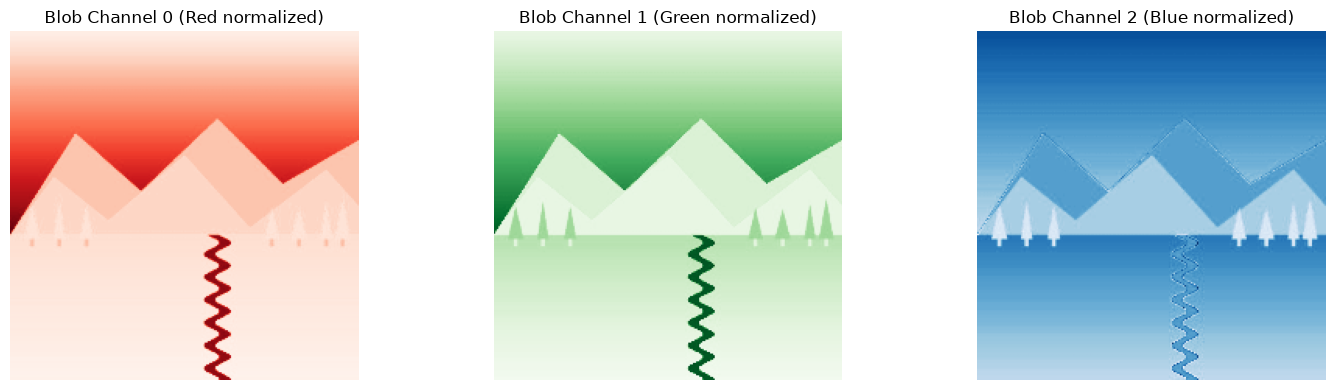

In [6]:
# Demonstrate 4D NCHW input blob construction for deep networks
sample_bgr = cv2.imread(os.path.join(img_dir, "landscape.jpg"))
assert sample_bgr is not None, "Failed to load landscape.jpg"

# Typical ImageNet normalization parameters: size 224x224, mean [123.68, 116.78, 103.94], scalefactor 1/255.0
blob = cv2.dnn.blobFromImage(
    sample_bgr,
    scalefactor=1.0 / 255.0,
    size=(224, 224),
    mean=(123.68, 116.78, 103.94),
    swapRB=True,
    crop=False
)

print(f"Constructed OpenCV DNN 4D Tensor Blob Shape: {blob.shape} (N, C, H, W)")
print(f"Blob dtype: {blob.dtype}, Min: {blob.min():.3f}, Max: {blob.max():.3f}")

# Visualize the 3 normalized channels fed into the deep network
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(blob[0, 0], cmap="Reds")
axes[0].set_title("Blob Channel 0 (Red normalized)")
axes[0].axis("off")

axes[1].imshow(blob[0, 1], cmap="Greens")
axes[1].set_title("Blob Channel 1 (Green normalized)")
axes[1].axis("off")

axes[2].imshow(blob[0, 2], cmap="Blues")
axes[2].set_title("Blob Channel 2 (Blue normalized)")
axes[2].axis("off")

plt.tight_layout()
plt.show()